# Model 3: Transfer Learning

In [ ]:
import torch

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install mtcnn -q

# Lock TensorFlow to CPU now, before PyTorch claims the GPU.
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
try:
    import tensorflow as _tf
    _tf.config.set_visible_devices([], 'GPU')
    del _tf
except ImportError:
    pass


import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
import torchvision
from torchvision import models
import matplotlib.pyplot as plt
import time
import copy

import os, random, shutil, sys
from torch.utils.data import DataLoader, Dataset
from matplotlib import patches

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'CW_Folder_UG'
GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', GOOGLE_DRIVE_PATH_AFTER_MYDRIVE)
print(os.listdir(GOOGLE_DRIVE_PATH))
CODE_PATH = os.path.abspath(f'{GOOGLE_DRIVE_PATH}/Code')

if CODE_PATH not in sys.path:
    sys.path.insert(0, CODE_PATH)

print(CODE_PATH)
print(os.path.exists(os.path.join(CODE_PATH, "utils.py")))

MODELS_DIR = os.path.join(GOOGLE_DRIVE_PATH, 'Models')
os.makedirs(MODELS_DIR, exist_ok=True)



import zipfile
from pathlib import Path

src = Path(GOOGLE_DRIVE_PATH) / "CW_Dataset"
dst = Path(GOOGLE_DRIVE_PATH) / "CW_Dataset.zip"

if not dst.exists():
  with zipfile.ZipFile(dst, "w", zipfile.ZIP_DEFLATED) as zf:
      for file in src.rglob("*"):
          zf.write(file, arcname=file.relative_to(src.parent))
  print(f"Created: {dst}")

!cp '{GOOGLE_DRIVE_PATH}/CW_Dataset.zip' .
!yes|unzip -q CW_Dataset.zip
!rm CW_Dataset.zip

LOCAL_ROOT = '/content'



from utils import *

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 109.1 MB/s eta 0:00:00
['Models', 'CW_Dataset', 'Personal_Dataset', 'Code', 'CW_Dataset.zip', 'Personal_Dataset.zip', 'test_function.ipynb']
/content/drive/My Drive/CW_Folder_UG/Code
True


In [ ]:
train_paths_all, train_labels_all, test_paths, test_labels = load_dataset(LOCAL_ROOT)

train_paths, val_paths, y_train, y_val = make_train_val_split(
    train_paths_all, train_labels_all, test_size=0.15)
y_train, y_val, y_test = np.array(y_train), np.array(y_val), np.array(test_labels)
print(f'Train:{len(train_paths)}  Val:{len(val_paths)}  Test:{len(test_paths)}')

Train: 13300 images
Test: 850 images
Train:11305  Val:1995  Test:850


# Transfer Learning

## Loading the Data

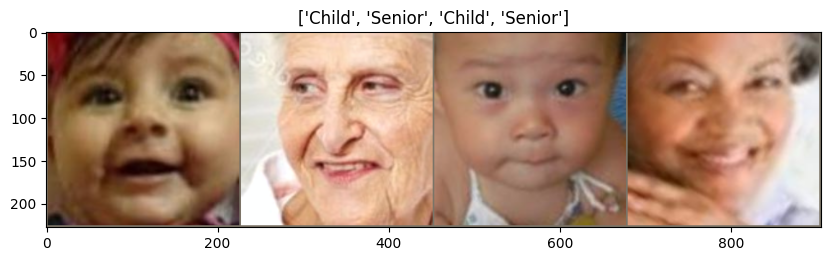

In [ ]:
# Reference: Lab_08_Solved.ipynb (Loading the Data)
data_means = [0.485, 0.456, 0.406]
data_stds  = [0.229, 0.224, 0.225]
class_names = [AGE_LABELS[i] for i in range(4)]

# Reference: Lab_08_Solved.ipynb (Loading the Data)
# Applies the same normalisation as data_transforms in the lab
class AgeDataset(Dataset):
    def __init__(self, paths, labels=None, image_size=(224,224),
                 augment=False, crop_face=False, match_resolution=False):
        self.paths = list(paths)
        self.labels = None if labels is None else list(labels)
        self.image_size = image_size
        self.augment = augment
        self.crop_face = crop_face
        self.match_resolution = match_resolution
        self.mean = np.array(data_means, dtype=np.float32)
        self.std  = np.array(data_stds,  dtype=np.float32)

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = read_rgb(self.paths[idx])
        if self.crop_face:      img = crop_largest_face(img)
        if self.match_resolution: img = match_dataset_resolution(img)
        img = resize_image(img, self.image_size)
        if self.augment:
            if random.random() < 0.5: img = np.fliplr(img)
            img = np.clip(img * random.uniform(0.85, 1.15), 0, 1)
        img = (img.astype(np.float32) - self.mean) / self.std
        x = torch.from_numpy(np.ascontiguousarray(np.transpose(img, (2,0,1)))).float()
        return x if self.labels is None else (x, torch.tensor(int(self.labels[idx]), dtype=torch.long))

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Reference: Lab_08_Solved.ipynb (Loading the Data)
dataloaders = {
    'train': DataLoader(AgeDataset(train_paths, y_train, IMAGE_SIZE, augment=True),
                        batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True),
    'val':   DataLoader(AgeDataset(val_paths,   y_val,   IMAGE_SIZE, augment=False),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
    'test':  DataLoader(AgeDataset(test_paths,  y_test,  IMAGE_SIZE, augment=False),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
}
dataset_sizes = {k: len(dataloaders[k].dataset) for k in dataloaders}

# Reference: Lab_08_Solved.ipynb (Visualizing a few images)
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    inp = np.asarray(data_stds) * inp + np.asarray(data_means)
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)

first_inputs, first_classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(first_inputs[:4])
plt.figure(figsize=(10, 4))
imshow(out, title=[class_names[x] for x in first_classes[:4]])
plt.show()

## Training the Model

In [ ]:
# Reference: Lab_08_Solved.ipynb (Training the model)
def train_model(model, criterion, optimizer, scheduler, num_epochs=25, patience=5):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    epochs_no_improve = 0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 16)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss    += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase} loss: {epoch_loss:.4f}  acc: {epoch_acc:.4f}')

            if phase == 'train':
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc.item())
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc.item())
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val acc: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, train_losses, train_accs, val_losses, val_accs

In [ ]:
# Class-weighted loss to address class imbalance (Lecture05/06)
counts = np.bincount(y_train, minlength=4).astype(np.float32)
class_weights = torch.tensor(counts.sum() / (4 * np.maximum(counts, 1))).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
import warnings; warnings.filterwarnings('ignore')

# Grid search over lr and weight_decay for the finetune model
GRID_EPOCHS  = 5
GRID_PATIENCE = 2

GRID_LRS = [1e-4, 5e-4, 1e-3]
GRID_WDS = [1e-5, 1e-4]

print(f"{'lr':>10} {'weight_decay':>14} {'val acc':>10}")
print('-' * 38)

best_lr, best_wd, best_acc = None, None, -1

for lr in GRID_LRS:
    for wd in GRID_WDS:
        torch.manual_seed(SEED)
        torch.cuda.manual_seed(SEED)

        trial = models.resnet18(weights='IMAGENET1K_V1')
        trial.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(trial.fc.in_features, len(class_names)))
        trial = trial.to(device)

        opt = optim.Adam(trial.parameters(), lr=lr, weight_decay=wd)
        sch = lr_scheduler.CosineAnnealingLR(opt, T_max=GRID_EPOCHS)

        _, _, _, _, val_accs = train_model(
            trial, criterion, opt, sch,
            num_epochs=GRID_EPOCHS, patience=GRID_PATIENCE)

        acc = max(val_accs)
        print(f"{lr:>10.0e} {wd:>14.0e} {acc:>10.4f}")

        if acc > best_acc:
            best_acc, best_lr, best_wd = acc, lr, wd

        del trial

print()
print(f'Best: lr={best_lr:.0e}  weight_decay={best_wd:.0e}  val_acc={best_acc:.4f}')

        lr   weight_decay    val acc
--------------------------------------
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 398MB/s]

Epoch 0/4
----------------


train loss: 0.6468  acc: 0.7149
val loss: 0.5099  acc: 0.7830

Epoch 1/4
----------------
train loss: 0.4471  acc: 0.8117
val loss: 0.5038  acc: 0.7559

Epoch 2/4
----------------
train loss: 0.3362  acc: 0.8617
val loss: 0.4805  acc: 0.8085

Epoch 3/4
----------------
train loss: 0.2181  acc: 0.9168
val loss: 0.4967  acc: 0.8160

Epoch 4/4
----------------
train loss: 0.1419  acc: 0.9536
val loss: 0.4881  acc: 0.8291

Training complete in 3m 4s
Best val acc: 0.8291
     1e-04          1e-05     0.8291
Epoch 0/4
----------------
train loss: 0.6450  acc: 0.7160
val loss: 0.5059  acc: 0.7799

Epoch 1/4
----------------
train loss: 0.4468  acc: 0.8110
val loss: 0.4923  acc: 0.7694

Epoch 2/4
----------------
train loss: 0.3390  acc: 0.8615
val loss: 0.4703  acc: 0.8125

Epoch 3/4
----------------
train loss: 0.2177  acc: 0.9168
val loss: 0.4944  acc: 0.8105

Epoch 4/4
----------------
train loss: 0.1463  acc: 0.9497
val loss: 0.4851  acc: 0.8150

Training complete in 2m 60s
Best val acc: 

## Finetuning the CNN

In [ ]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Reference: Lab_08_Solved.ipynb (Finetuning the CNN)
model_ft = models.resnet18(weights='IMAGENET1K_V1')

# Reference: Lab_08_Solved.ipynb (Finetuning the CNN)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(num_ftrs, len(class_names)))

model_ft = model_ft.to(device)


# Reference: Lab_08_Solved.ipynb (Finetuning the CNN)
optimizer_ft = optim.Adam(model_ft.parameters(), lr=best_lr, weight_decay=best_wd)
exp_lr_scheduler = lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=15)

In [ ]:
# Reference: Lab_08_Solved.ipynb (Train and evaluate)
model_ft, train_losses, train_accs, val_losses, val_accs = train_model(
    model_ft, criterion, optimizer_ft, exp_lr_scheduler,
    num_epochs=25, patience=5)

Epoch 0/24
----------------
train loss: 0.6725  acc: 0.7098
val loss: 0.5425  acc: 0.7624

Epoch 1/24
----------------
train loss: 0.5209  acc: 0.7778
val loss: 0.6713  acc: 0.7544

Epoch 2/24
----------------
train loss: 0.4712  acc: 0.8034
val loss: 0.5274  acc: 0.7619

Epoch 3/24
----------------
train loss: 0.4221  acc: 0.8241
val loss: 0.4689  acc: 0.7925

Epoch 4/24
----------------
train loss: 0.3892  acc: 0.8378
val loss: 0.4794  acc: 0.7925

Epoch 5/24
----------------
train loss: 0.3422  acc: 0.8563
val loss: 0.4840  acc: 0.7930

Epoch 6/24
----------------
train loss: 0.2867  acc: 0.8833
val loss: 0.5620  acc: 0.8100

Epoch 7/24
----------------
train loss: 0.2303  acc: 0.9097
val loss: 0.5272  acc: 0.8065

Epoch 8/24
----------------
train loss: 0.1778  acc: 0.9352
val loss: 0.5607  acc: 0.8140

Epoch 9/24
----------------
train loss: 0.1126  acc: 0.9606
val loss: 0.6567  acc: 0.8110

Epoch 10/24
----------------
train loss: 0.0748  acc: 0.9748
val loss: 0.7068  acc: 0.8241

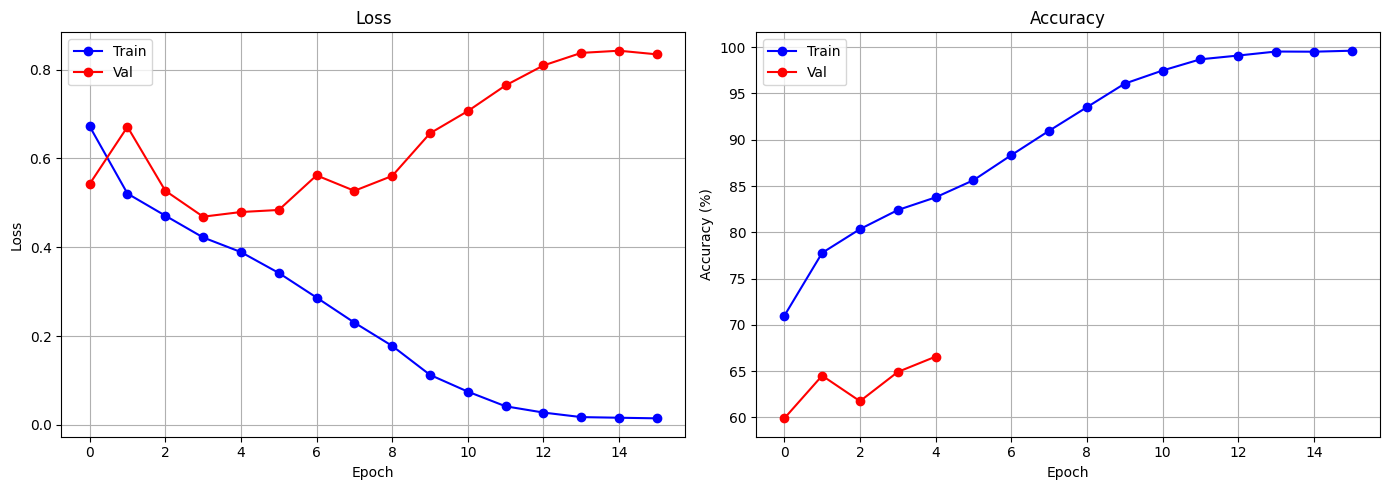

In [19]:
# Reference: Lab_08_Solved.ipynb (Training curves)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, 'b-o', label='Train')
ax1.plot(val_losses,   'r-o', label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot([a * 100 for a in train_accs], 'b-o', label='Train')
ax2.plot([a * 100 for a in val_accs],   'r-o', label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Finetune: Test set
              precision    recall  f1-score   support

       Child       0.90      0.97      0.93       150
       Young       0.88      0.87      0.88       350
 Middle-Aged       0.66      0.65      0.65       200
      Senior       0.76      0.72      0.74       150

    accuracy                           0.81       850
   macro avg       0.80      0.80      0.80       850
weighted avg       0.81      0.81      0.81       850



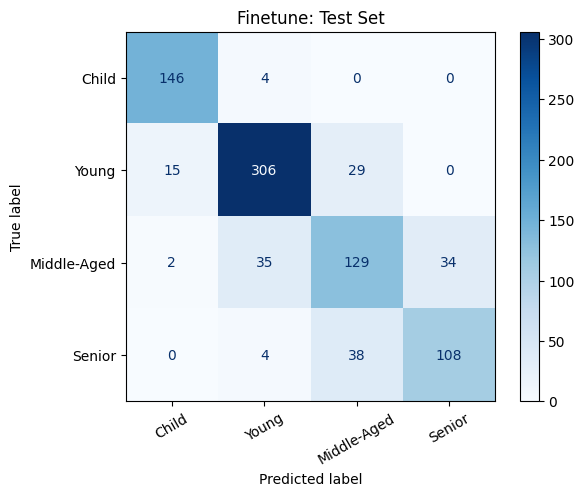

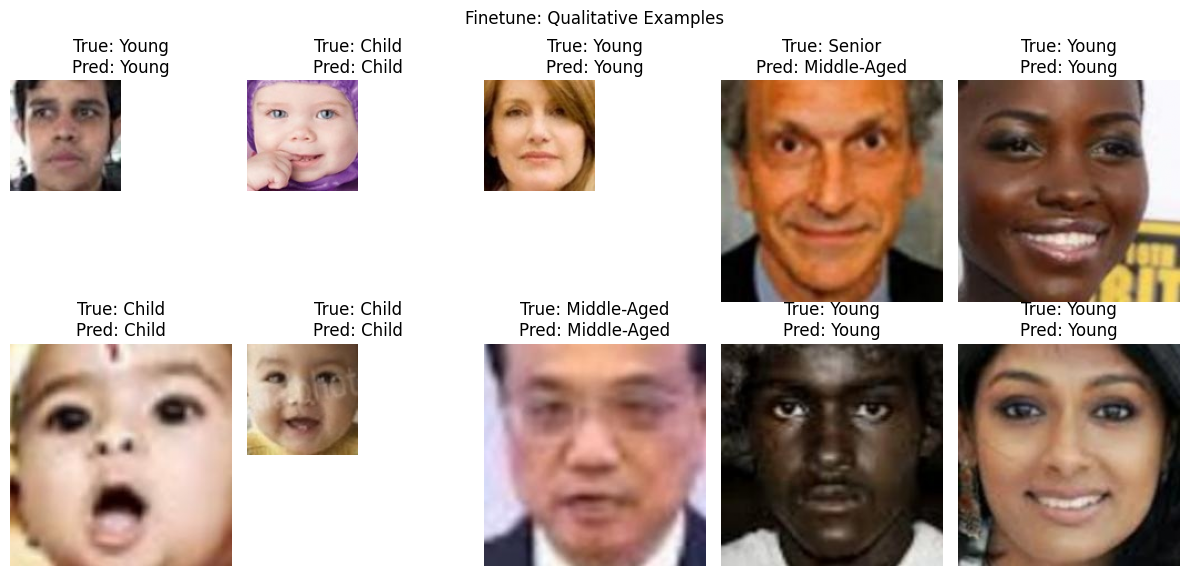

Saved model_3_finetune.pt


In [20]:
model_ft.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        outputs = model_ft(inputs.to(device))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print('Finetune: Test set')
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))
cm = confusion_matrix(all_labels, all_preds, labels=list(range(4)))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', xticks_rotation=30)
plt.title('Finetune: Test Set')
plt.show()

sample_idx = np.random.default_rng(SEED).choice(len(test_paths), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(12, 6), sharex=True, sharey=True)
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(read_rgb(test_paths[idx]))
    ax.set_title(f'True: {class_names[int(y_test[idx])]}\nPred: {class_names[int(all_preds[idx])]}')
    ax.axis('off')
plt.suptitle('Finetune: Qualitative Examples')
plt.tight_layout()
plt.show()

# Reference: Lab_08_Solved.ipynb (Saving the model)
torch.save(model_ft.state_dict(), os.path.join(MODELS_DIR, 'model_3_finetune.pt'))
print('Saved model_3_finetune.pt')

In [ ]:
mb = os.path.getsize(os.path.join(MODELS_DIR, 'model_3_finetune.pt')) / 1e6
print(f'ResNet18 Finetune  {mb:.2f} MB')

ResNet18 Finetune  44.79 MB


## CNN as Fixed Feature Extractor

In [ ]:
import warnings; warnings.filterwarnings('ignore')

# Grid search over lr and weight_decay for the frozen (fixed feature extractor) model
GRID_EPOCHS  = 5
GRID_PATIENCE = 2

GRID_LRS = [1e-4, 5e-4, 1e-3]
GRID_WDS = [1e-5, 1e-4]

print(f"{'lr':>10} {'weight_decay':>14} {'val acc':>10}")
print('-' * 38)

best_lr_conv, best_wd_conv, best_acc_conv = None, None, -1

for lr in GRID_LRS:
    for wd in GRID_WDS:
        torch.manual_seed(SEED)
        torch.cuda.manual_seed(SEED)

        trial = models.resnet18(weights='IMAGENET1K_V1')
        for param in trial.parameters():
            param.requires_grad = False
        trial.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(trial.fc.in_features, len(class_names)))
        trial = trial.to(device)

        opt = optim.Adam(trial.fc.parameters(), lr=lr, weight_decay=wd)
        sch = lr_scheduler.CosineAnnealingLR(opt, T_max=GRID_EPOCHS)

        _, _, _, _, val_accs = train_model(
            trial, criterion, opt, sch,
            num_epochs=GRID_EPOCHS, patience=GRID_PATIENCE)

        acc = max(val_accs)
        print(f"{lr:>10.0e} {wd:>14.0e} {acc:>10.4f}")

        if acc > best_acc_conv:
            best_acc_conv, best_lr_conv, best_wd_conv = acc, lr, wd

        del trial

print()
print(f'Best: lr={best_lr_conv:.0e}  weight_decay={best_wd_conv:.0e}  val_acc={best_acc_conv:.4f}')

        lr   weight_decay    val acc
--------------------------------------
Epoch 0/4
----------------
train loss: 1.3243  acc: 0.3633
val loss: 1.1483  acc: 0.4927

Epoch 1/4
----------------
train loss: 1.1005  acc: 0.5131
val loss: 1.0193  acc: 0.5409

Epoch 2/4
----------------
train loss: 1.0271  acc: 0.5408
val loss: 0.9651  acc: 0.5855

Epoch 3/4
----------------
train loss: 0.9894  acc: 0.5640
val loss: 0.9480  acc: 0.5900

Epoch 4/4
----------------
train loss: 0.9760  acc: 0.5668
val loss: 0.9418  acc: 0.5985

Training complete in 3m 1s
Best val acc: 0.5985
     1e-04          1e-05     0.5985
Epoch 0/4
----------------
train loss: 1.3243  acc: 0.3633
val loss: 1.1483  acc: 0.4927

Epoch 1/4
----------------
train loss: 1.1005  acc: 0.5131
val loss: 1.0193  acc: 0.5409

Epoch 2/4
----------------
train loss: 1.0271  acc: 0.5408
val loss: 0.9651  acc: 0.5855

Epoch 3/4
----------------
train loss: 0.9894  acc: 0.5638
val loss: 0.9480  acc: 0.5900

Epoch 4/4
----------------
tr

In [ ]:
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Reference: Lab_08_Solved.ipynb (Task 1.1: Train a CNN as fixed feature extractor)
model_conv = models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Sequential(nn.Dropout(0.2), nn.Linear(num_ftrs, len(class_names)))

model_conv = model_conv.to(device)

# Reference: Lab_08_Solved.ipynb (Task 1.1: Train a CNN as fixed feature extractor)
optimizer_conv = optim.Adam(model_conv.fc.parameters(), lr=best_lr_conv, weight_decay=best_wd_conv)
exp_lr_scheduler_conv = lr_scheduler.CosineAnnealingLR(optimizer_conv, T_max=15)

In [15]:
# Reference: Lab_08_Solved.ipynb (Task 1.1: Train a CNN as fixed feature extractor)
model_conv, train_losses_conv, train_accs_conv, val_losses_conv, val_accs_conv = train_model(
    model_conv, criterion, optimizer_conv, exp_lr_scheduler_conv,
    num_epochs=25, patience=5)

Epoch 0/24
----------------
train loss: 1.0119  acc: 0.5413
val loss: 0.8415  acc: 0.5990

Epoch 1/24
----------------
train loss: 0.8588  acc: 0.6152
val loss: 0.8036  acc: 0.6431

Epoch 2/24
----------------
train loss: 0.8464  acc: 0.6223
val loss: 0.7962  acc: 0.6025

Epoch 3/24
----------------
train loss: 0.8355  acc: 0.6280
val loss: 0.7905  acc: 0.6286

Epoch 4/24
----------------
train loss: 0.8312  acc: 0.6317
val loss: 0.7667  acc: 0.6817

Epoch 5/24
----------------
train loss: 0.8194  acc: 0.6369
val loss: 0.7591  acc: 0.6561

Epoch 6/24
----------------
train loss: 0.8152  acc: 0.6349
val loss: 0.7424  acc: 0.6722

Epoch 7/24
----------------
train loss: 0.8052  acc: 0.6379
val loss: 0.7503  acc: 0.6551

Epoch 8/24
----------------
train loss: 0.8059  acc: 0.6453
val loss: 0.7533  acc: 0.6667

Epoch 9/24
----------------
train loss: 0.7974  acc: 0.6461
val loss: 0.7477  acc: 0.6732
Early stopping at epoch 10
Training complete in 6m 0s
Best val acc: 0.6817


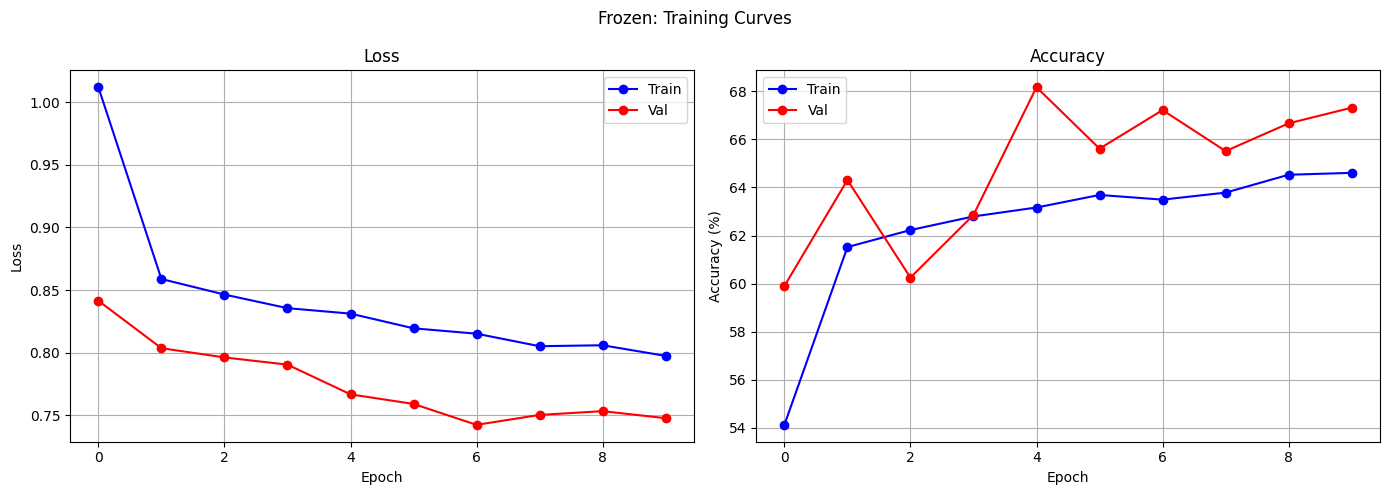

In [16]:
# Reference: Lab_08_Solved.ipynb (Training curves)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_conv, 'b-o', label='Train')
ax1.plot(val_losses_conv,   'r-o', label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot([a * 100 for a in train_accs_conv], 'b-o', label='Train')
ax2.plot([a * 100 for a in val_accs_conv],   'r-o', label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True)

plt.suptitle('Frozen: Training Curves')
plt.tight_layout()
plt.show()

Frozen: Test set
              precision    recall  f1-score   support

       Child       0.75      0.83      0.78       150
       Young       0.75      0.72      0.73       350
 Middle-Aged       0.47      0.52      0.49       200
      Senior       0.67      0.55      0.60       150

    accuracy                           0.66       850
   macro avg       0.66      0.65      0.65       850
weighted avg       0.67      0.66      0.66       850



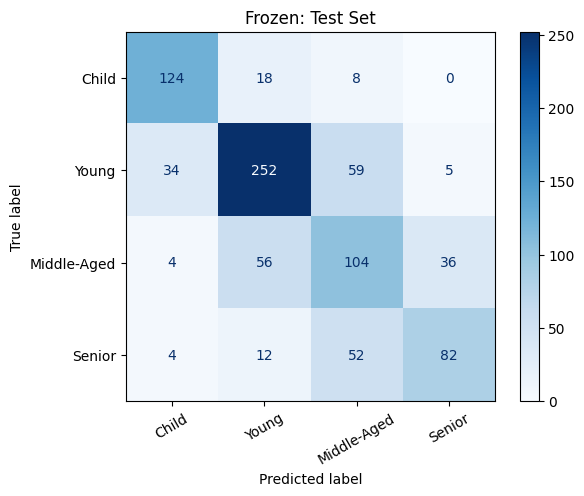

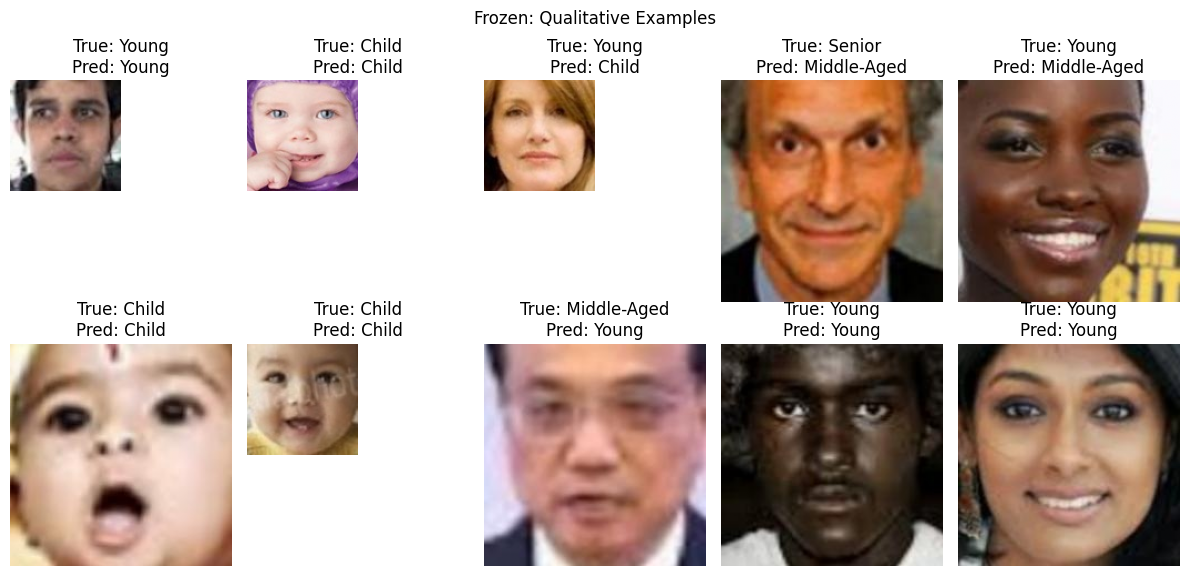

Saved model_3_frozen.pt


In [17]:
model_conv.eval()
all_preds_conv, all_labels_conv = [], []
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        outputs = model_conv(inputs.to(device))
        all_preds_conv.extend(outputs.argmax(1).cpu().numpy())
        all_labels_conv.extend(labels.numpy())

print('Frozen: Test set')
print(classification_report(all_labels_conv, all_preds_conv, target_names=class_names, zero_division=0))
cm = confusion_matrix(all_labels_conv, all_preds_conv, labels=list(range(4)))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', xticks_rotation=30)
plt.title('Frozen: Test Set')
plt.show()

sample_idx = np.random.default_rng(SEED).choice(len(test_paths), size=10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(12, 6), sharex=True, sharey=True)
for ax, idx in zip(axes.ravel(), sample_idx):
    ax.imshow(read_rgb(test_paths[idx]))
    ax.set_title(f'True: {class_names[int(y_test[idx])]}\nPred: {class_names[int(all_preds_conv[idx])]}')
    ax.axis('off')
plt.suptitle('Frozen: Qualitative Examples')
plt.tight_layout()
plt.show()

torch.save(model_conv.state_dict(), os.path.join(MODELS_DIR, 'model_3_frozen.pt'))
print('Saved model_3_frozen.pt')

In [18]:
mb = os.path.getsize(os.path.join(MODELS_DIR, 'model_3_frozen.pt')) / 1e6
print(f'ResNet18 Frozen    {mb:.2f} MB')

ResNet18 Frozen    44.79 MB
